# Ising Critical Scaling and Maxwell Gas Statistics

Ising magnetization fits, specific heat, susceptibility scaling collapse, and a Lennard–Jones gas speed distribution compared with the two-dimensional Maxwell law.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


T = 2.0000 done: <|m|> = 0.911444 ± 0.001045
T = 2.0400 done: <|m|> = 0.896820 ± 0.000578
T = 2.0800 done: <|m|> = 0.879591 ± 0.001085
T = 2.1200 done: <|m|> = 0.856914 ± 0.000742
T = 2.1600 done: <|m|> = 0.825385 ± 0.002256
T = 2.1800 done: <|m|> = 0.812341 ± 0.003274
T = 2.2000 done: <|m|> = 0.789129 ± 0.003334
T = 2.2200 done: <|m|> = 0.752637 ± 0.009973
T = 2.2300 done: <|m|> = 0.728425 ± 0.005968
T = 2.2400 done: <|m|> = 0.699556 ± 0.025217
T = 2.2450 done: <|m|> = 0.645299 ± 0.071456
T = 2.2500 done: <|m|> = 0.675798 ± 0.032743
T = 2.2550 done: <|m|> = 0.662317 ± 0.029197
T = 2.2600 done: <|m|> = 0.653416 ± 0.018642
T = 2.2650 done: <|m|> = 0.612158 ± 0.020377

SUMMARY
Lattice size L = 64
Exact square-lattice Tc = 2.269185

Method 1: log(M) vs log(Tc - T) using exact Tc
  beta = 0.112189
  R^2  = 0.958094

Method 2: scan trial Tc values
  Best Tc trial = 2.280000
  beta          = 0.139606
  R^2           = 0.969132

Expected exact beta = 1/8 = 0.125


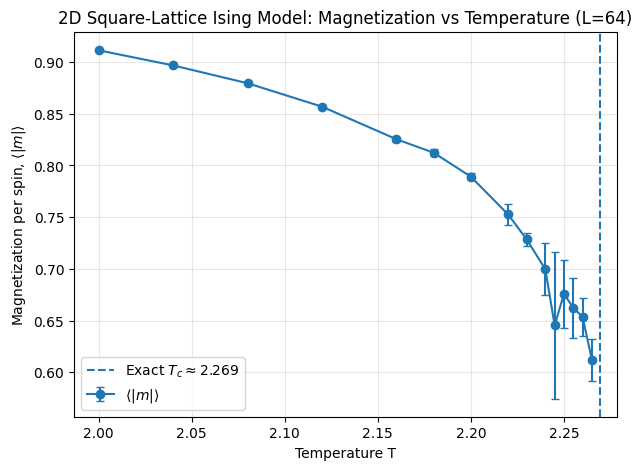

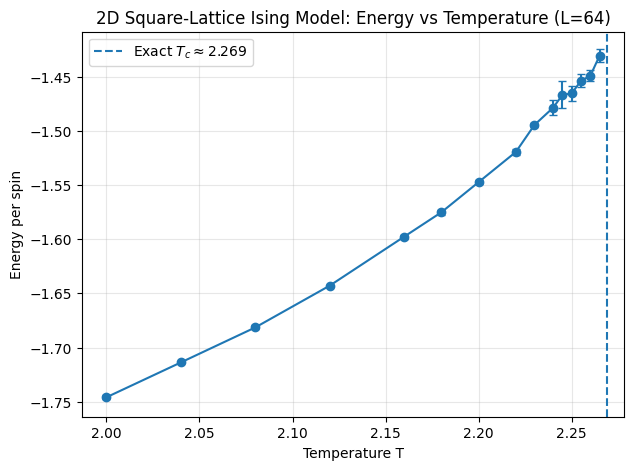

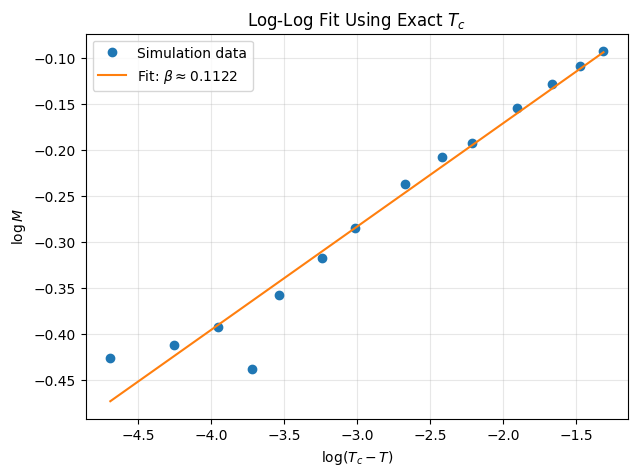

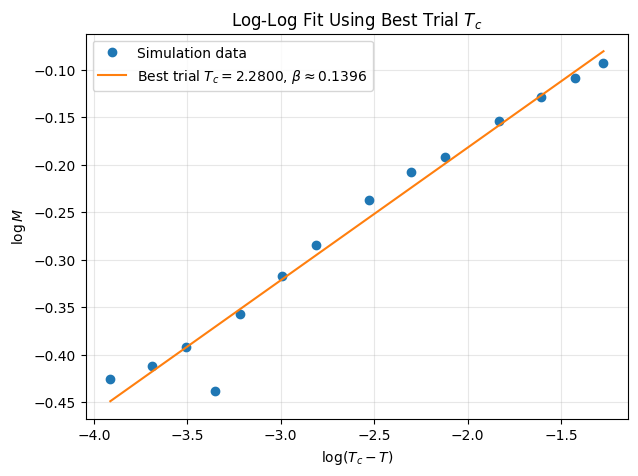


Temperature table:
   T        <|m|>        SEM(|m|)      <e>          SEM(e)
 2.0000     0.911444     0.001045    -1.745916     0.001789
 2.0400     0.896820     0.000578    -1.713747     0.000277
 2.0800     0.879591     0.001085    -1.681437     0.001889
 2.1200     0.856914     0.000742    -1.642861     0.000594
 2.1600     0.825385     0.002256    -1.597690     0.001847
 2.1800     0.812341     0.003274    -1.575153     0.002455
 2.2000     0.789129     0.003334    -1.547342     0.001847
 2.2200     0.752637     0.009973    -1.519507     0.002569
 2.2300     0.728425     0.005968    -1.494569     0.001489
 2.2400     0.699556     0.025217    -1.478696     0.007042
 2.2450     0.645299     0.071456    -1.466917     0.012455
 2.2500     0.675798     0.032743    -1.465487     0.007037
 2.2550     0.662317     0.029197    -1.453879     0.005845
 2.2600     0.653416     0.018642    -1.449237     0.004945
 2.2650     0.612158     0.020377    -1.430633     0.005920


In [ ]:
# Fast 2D square-lattice Ising model in Google Colab
# Metropolis algorithm with checkerboard updates
# Estimates beta from M(T)

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# User inputs
# ============================================================

L = 64
J = 1.0
kB = 1.0
Tc_exact = 2.0 / np.log(1.0 + np.sqrt(2.0))   # exact Tc for square lattice, J=kB=1

temps = np.array([
    2.00, 2.04, 2.08, 2.12, 2.16,
    2.18, 2.20, 2.22, 2.23, 2.24,
    2.245, 2.25, 2.255, 2.26, 2.265
])

# Faster but still decent statistics
n_equil = 1500
n_meas = 2000
measure_every = 10
n_runs = 3
seed = 12345

T_fit_min = 2.00
T_fit_max = 2.26
beta_trials = [0.10, 0.115, 0.125, 0.135, 0.15]
Tc_trials = np.linspace(2.255, 2.280, 101)

# ============================================================
# Checkerboard masks
# ============================================================

ii, jj = np.indices((L, L))
mask_even = ((ii + jj) % 2 == 0)
mask_odd = ~mask_even

# ============================================================
# Core routines
# ============================================================

def init_lattice(L, mode="hot", rng=None):
    if rng is None:
        rng = np.random.default_rng()
    if mode == "hot":
        return rng.choice(np.array([-1, 1], dtype=np.int8), size=(L, L))
    elif mode == "cold":
        return np.ones((L, L), dtype=np.int8)
    else:
        raise ValueError("mode must be 'hot' or 'cold'")

def neighbor_sum(spins):
    return (
        np.roll(spins, 1, axis=0) +
        np.roll(spins, -1, axis=0) +
        np.roll(spins, 1, axis=1) +
        np.roll(spins, -1, axis=1)
    )

def metropolis_half_sweep(spins, T, rng, mask):
    nn = neighbor_sum(spins)
    dE = 2.0 * J * spins * nn

    # Acceptance test only on one checkerboard sublattice
    rand = rng.random(spins.shape)
    accept = mask & ((dE <= 0.0) | (rand < np.exp(-dE / T)))

    spins[accept] *= -1

def metropolis_sweep(spins, T, rng):
    metropolis_half_sweep(spins, T, rng, mask_even)
    metropolis_half_sweep(spins, T, rng, mask_odd)

def total_energy(spins):
    right = np.roll(spins, -1, axis=1)
    down = np.roll(spins, -1, axis=0)
    return -J * np.sum(spins * (right + down))

def magnetization_per_spin(spins):
    return np.mean(spins)

def run_one_temperature(T, rng, start_mode="hot"):
    spins = init_lattice(L, mode=start_mode, rng=rng)

    # Equilibrate
    for _ in range(n_equil):
        metropolis_sweep(spins, T, rng)

    abs_m_samples = []
    e_samples = []

    for sweep in range(n_meas):
        metropolis_sweep(spins, T, rng)

        if (sweep + 1) % measure_every == 0:
            abs_m_samples.append(abs(magnetization_per_spin(spins)))
            e_samples.append(total_energy(spins) / (L * L))

    return np.array(abs_m_samples), np.array(e_samples)

def simulate_vs_temperature():
    rng_master = np.random.default_rng(seed)

    M_mean, M_sem = [], []
    E_mean, E_sem = [], []

    for T in temps:
        run_means_M = []
        run_means_E = []

        for _ in range(n_runs):
            rng = np.random.default_rng(int(rng_master.integers(0, 2**32 - 1)))
            abs_m_samples, e_samples = run_one_temperature(T, rng, start_mode="hot")
            run_means_M.append(np.mean(abs_m_samples))
            run_means_E.append(np.mean(e_samples))

        run_means_M = np.array(run_means_M)
        run_means_E = np.array(run_means_E)

        M_mean.append(np.mean(run_means_M))
        M_sem.append(np.std(run_means_M, ddof=1) / np.sqrt(n_runs) if n_runs > 1 else 0.0)
        E_mean.append(np.mean(run_means_E))
        E_sem.append(np.std(run_means_E, ddof=1) / np.sqrt(n_runs) if n_runs > 1 else 0.0)

        print(f"T = {T:.4f} done: <|m|> = {M_mean[-1]:.6f} ± {M_sem[-1]:.6f}")

    return np.array(M_mean), np.array(M_sem), np.array(E_mean), np.array(E_sem)

# ============================================================
# Analysis helpers
# ============================================================

def linear_fit(x, y):
    coeffs = np.polyfit(x, y, 1)
    b, a = coeffs[0], coeffs[1]
    yhat = a + b * x
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 1.0
    return a, b, r2

def fit_beta_given_Tc(temps, M, Tc, Tmin, Tmax):
    mask = (temps >= Tmin) & (temps <= Tmax) & (temps < Tc) & (M > 0)
    Tsel = temps[mask]
    Msel = M[mask]
    x = np.log(Tc - Tsel)
    y = np.log(Msel)
    a, b, r2 = linear_fit(x, y)
    return b, a, r2, x, y, Tsel, Msel

def scan_trial_Tc(temps, M, Tmin, Tmax, Tc_trials):
    best = None
    results = []
    for Tc in Tc_trials:
        try:
            beta, lnA, r2, x, y, Tsel, Msel = fit_beta_given_Tc(temps, M, Tc, Tmin, Tmax)
            if len(Tsel) >= 5:
                results.append((Tc, beta, lnA, r2, len(Tsel)))
                if (best is None) or (r2 > best[3]):
                    best = (Tc, beta, lnA, r2, len(Tsel))
        except Exception:
            pass
    if best is None:
        raise RuntimeError("No valid Tc trial fit found.")
    return best, results

def linearity_score_for_beta_trial(temps, M, beta_trial, Tmin, Tmax):
    mask = (temps >= Tmin) & (temps <= Tmax) & (M > 0)
    Tsel = temps[mask]
    Ysel = M[mask] ** (1.0 / beta_trial)
    a, b, r2 = linear_fit(Tsel, Ysel)
    return a, b, r2, Tsel, Ysel

# ============================================================
# Run
# ============================================================

M_mean, M_sem, E_mean, E_sem = simulate_vs_temperature()

beta_exactTc, lnA_exactTc, r2_exactTc, x_exactTc, y_exactTc, Tsel_exactTc, Msel_exactTc = fit_beta_given_Tc(
    temps, M_mean, Tc_exact, T_fit_min, T_fit_max
)

best_trial, trial_results = scan_trial_Tc(
    temps, M_mean, T_fit_min, T_fit_max, Tc_trials
)
Tc_best, beta_best, lnA_best, r2_best, npts_best = best_trial

trial_beta_results = []
for bt in beta_trials:
    a, b, r2, Tsel_bt, Ysel_bt = linearity_score_for_beta_trial(
        temps, M_mean, bt, T_fit_min, T_fit_max
    )
    trial_beta_results.append((bt, a, b, r2, Tsel_bt, Ysel_bt))

best_beta_trial = max(trial_beta_results, key=lambda item: item[3])

# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Lattice size L = {L}")
print(f"Exact square-lattice Tc = {Tc_exact:.6f}")
print()
print("Method 1: log(M) vs log(Tc - T) using exact Tc")
print(f"  beta = {beta_exactTc:.6f}")
print(f"  R^2  = {r2_exactTc:.6f}")
print()
print("Method 2: scan trial Tc values")
print(f"  Best Tc trial = {Tc_best:.6f}")
print(f"  beta          = {beta_best:.6f}")
print(f"  R^2           = {r2_best:.6f}")
print()
# print("Method 3: trial-beta linearization")
# print(f"  Best beta* by linearity = {best_beta_trial[0]:.6f}")
# print(f"  R^2                     = {best_beta_trial[3]:.6f}")
# print()
print("Expected exact beta = 1/8 = 0.125")
print("=" * 70)

# ============================================================
# Plots
# ============================================================

plt.figure(figsize=(7, 5))
plt.errorbar(temps, M_mean, yerr=M_sem, fmt='o-', capsize=3, label=r'$\langle |m| \rangle$')
plt.axvline(Tc_exact, linestyle='--', label=fr'Exact $T_c \approx {Tc_exact:.3f}$')
plt.xlabel('Temperature T')
plt.ylabel(r'Magnetization per spin, $\langle |m| \rangle$')
plt.title(f'2D Square-Lattice Ising Model: Magnetization vs Temperature (L={L})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.errorbar(temps, E_mean, yerr=E_sem, fmt='o-', capsize=3)
plt.axvline(Tc_exact, linestyle='--', label=fr'Exact $T_c \approx {Tc_exact:.3f}$')
plt.xlabel('Temperature T')
plt.ylabel('Energy per spin')
plt.title(f'2D Square-Lattice Ising Model: Energy vs Temperature (L={L})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(x_exactTc, y_exactTc, 'o', label='Simulation data')
xline = np.linspace(np.min(x_exactTc), np.max(x_exactTc), 200)
yline = lnA_exactTc + beta_exactTc * xline
plt.plot(xline, yline, '-', label=fr'Fit: $\beta \approx {beta_exactTc:.4f}$')
plt.xlabel(r'$\log(T_c - T)$')
plt.ylabel(r'$\log M$')
plt.title('Log-Log Fit Using Exact $T_c$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

beta_plot, lnA_plot, r2_plot, x_plot, y_plot, Tsel_plot, Msel_plot = fit_beta_given_Tc(
    temps, M_mean, Tc_best, T_fit_min, T_fit_max
)

plt.figure(figsize=(7, 5))
plt.plot(x_plot, y_plot, 'o', label='Simulation data')
xline = np.linspace(np.min(x_plot), np.max(x_plot), 200)
yline = lnA_plot + beta_plot * xline
plt.plot(xline, yline, '-', label=fr'Best trial $T_c={Tc_best:.4f}$, $\beta \approx {beta_plot:.4f}$')
plt.xlabel(r'$\log(T_c - T)$')
plt.ylabel(r'$\log M$')
plt.title('Log-Log Fit Using Best Trial $T_c$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\nTemperature table:")
print("   T        <|m|>        SEM(|m|)      <e>          SEM(e)")
for T, m, dm, e, de in zip(temps, M_mean, M_sem, E_mean, E_sem):
    print(f"{T:7.4f}   {m:10.6f}   {dm:10.6f}   {e:10.6f}   {de:10.6f}")

In [ ]:
# Problem 1 Snippets

# Checkerboard masks
ii, jj = np.indices((L, L));
mask_even = ((ii + jj) % 2 == 0);
mask_odd = ~mask_even;

# Lattice construction
def init_lattice(L, mode = "hot", rng = None):
    if rng is None:
        rng = np.random.default_rng();
    if mode == "hot":
        return rng.choice(np.array([-1, 1], dtype = np.int8), size = (L, L));
    elif mode == "cold":
        return np.ones((L, L), dtype = np.int8);
    else:
        raise ValueError("mode must be 'hot' or 'cold'");


def metropolis_half_sweep(spins, T, rng, mask):
    nn = neighbor_sum(spins);
    dE = 2.0 * J * spins * nn;
    # Acceptance test only on one checkerboard sublattice
    rand = rng.random(spins.shape);
    accept = mask & ((dE <= 0.0) | (rand < np.exp(-dE / T)));
    spins[accept] *= -1;


def metropolis_sweep(spins, T, rng):
    metropolis_half_sweep(spins, T, rng, mask_even);
    metropolis_half_sweep(spins, T, rng, mask_odd);

def total_energy(spins):
    right = np.roll(spins, -1, axis = 1);
    down = np.roll(spins, -1, axis = 0);
    return -J * np.sum(spins * (right + down));


def run_one_temperature(T, rng, start_mode = "hot"):
    spins = init_lattice(L, mode = start_mode, rng = rng);
    # Equilibrate
    for _ in range(n_equil):
        metropolis_sweep(spins, T, rng);
    #endfor
    abs_m_samples = [];
    e_samples = [];

    for sweep in range(n_meas):
        metropolis_sweep(spins, T, rng);
        if (sweep + 1) % measure_every == 0:
            abs_m_samples.append(abs(magnetization_per_spin(spins)));
            e_samples.append(total_energy(spins) / (L * L));
    #endfor
    return np.array(abs_m_samples), np.array(e_samples);

def simulate_vs_temperature():
    rng_master = np.random.default_rng(seed);
    M_mean, M_sem = [], [];
    E_mean, E_sem = [], [];

    for T in temps:
        run_means_M = [];
        run_means_E = [];
        for _ in range(n_runs):
            rng = np.random.default_rng(int(rng_master.integers(0, 2**32 - 1)));
            abs_m_samples, e_samples = run_one_temperature(T, rng, start_mode = "hot");
            run_means_M.append(np.mean(abs_m_samples));
            run_means_E.append(np.mean(e_samples));
        #endfor

        run_means_M = np.array(run_means_M);
        run_means_E = np.array(run_means_E);
        M_mean.append(np.mean(run_means_M));
        M_sem.append(np.std(run_means_M, ddof = 1) / np.sqrt(n_runs) if n_runs > 1 else 0.0);
        E_mean.append(np.mean(run_means_E));
        E_sem.append(np.std(run_means_E, ddof = 1) / np.sqrt(n_runs) if n_runs > 1 else 0.0);

        print(f"T = {T:.4f} done: <|m|> = {M_mean[-1]:.6f} ± {M_sem[-1]:.6f}");

    return np.array(M_mean), np.array(M_sem), np.array(E_mean), np.array(E_sem);


def linear_fit(x, y):
    coeffs = np.polyfit(x, y, 1);
    b, a = coeffs[0], coeffs[1];
    yhat = a + b * x;
    ss_res = np.sum((y - yhat)**2);
    ss_tot = np.sum((y - np.mean(y))**2);
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 1.0;
    return a, b, r2;

def fit_beta_given_Tc(temps, M, Tc, Tmin, Tmax):
    mask = (temps >= Tmin) & (temps <= Tmax) & (temps < Tc) & (M > 0);
    Tsel = temps[mask];
    Msel = M[mask];
    x = np.log(Tc - Tsel);
    y = np.log(Msel);
    a, b, r2 = linear_fit(x, y);
    return b, a, r2, x, y, Tsel, Msel;

def scan_trial_Tc(temps, M, Tmin, Tmax, Tc_trials):
    best = None;
    results = [];
    for Tc in Tc_trials:
        try:
            beta, lnA, r2, x, y, Tsel, Msel = fit_beta_given_Tc(temps, M, Tc, Tmin, Tmax);
            if len(Tsel) >= 5:
                results.append((Tc, beta, lnA, r2, len(Tsel)));
                if (best is None) or (r2 > best[3]):
                    best = (Tc, beta, lnA, r2, len(Tsel));
        except Exception:
            pass;
    if best is None:
        raise RuntimeError("No valid Tc trial fit found.");
    #endfor
    return best, results;

T = 1.00 done: <e> = -1.997350 ± 0.000149, C/N (fluct) = 0.022642 ± 0.001605
T = 1.10 done: <e> = -1.993990 ± 0.000198, C/N (fluct) = 0.041157 ± 0.001384
T = 1.20 done: <e> = -1.988845 ± 0.000177, C/N (fluct) = 0.065052 ± 0.001440
T = 1.30 done: <e> = -1.980325 ± 0.000368, C/N (fluct) = 0.101997 ± 0.002277
T = 1.40 done: <e> = -1.968990 ± 0.000446, C/N (fluct) = 0.140520 ± 0.002291
T = 1.50 done: <e> = -1.950300 ± 0.000829, C/N (fluct) = 0.203853 ± 0.006209
T = 1.60 done: <e> = -1.926635 ± 0.001199, C/N (fluct) = 0.267207 ± 0.005672
T = 1.70 done: <e> = -1.898400 ± 0.001127, C/N (fluct) = 0.337639 ± 0.005828
T = 1.80 done: <e> = -1.859145 ± 0.001587, C/N (fluct) = 0.446594 ± 0.009717
T = 1.90 done: <e> = -1.810035 ± 0.001913, C/N (fluct) = 0.572440 ± 0.010117
T = 2.00 done: <e> = -1.748380 ± 0.001856, C/N (fluct) = 0.692882 ± 0.008685
T = 2.10 done: <e> = -1.662035 ± 0.002498, C/N (fluct) = 0.941283 ± 0.013307
T = 2.20 done: <e> = -1.556350 ± 0.002278, C/N (fluct) = 1.159478 ± 0.020522

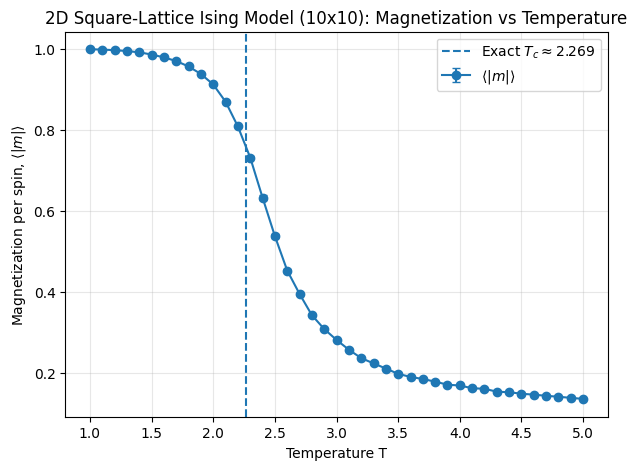

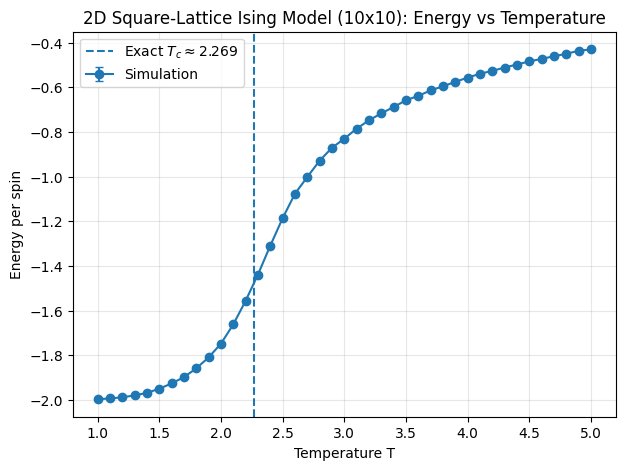

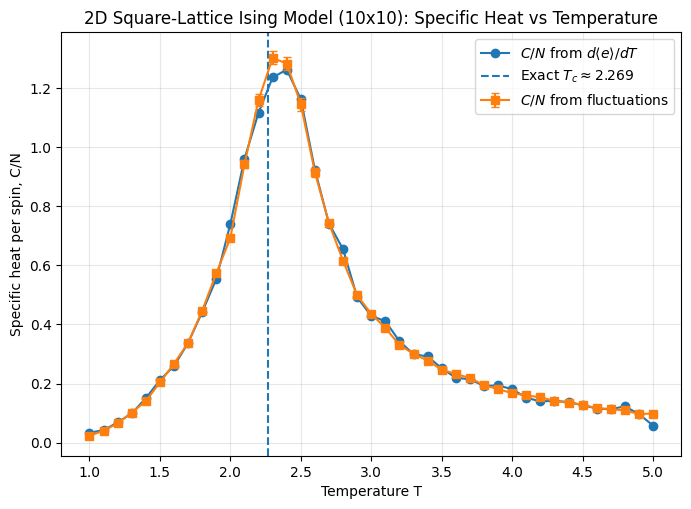

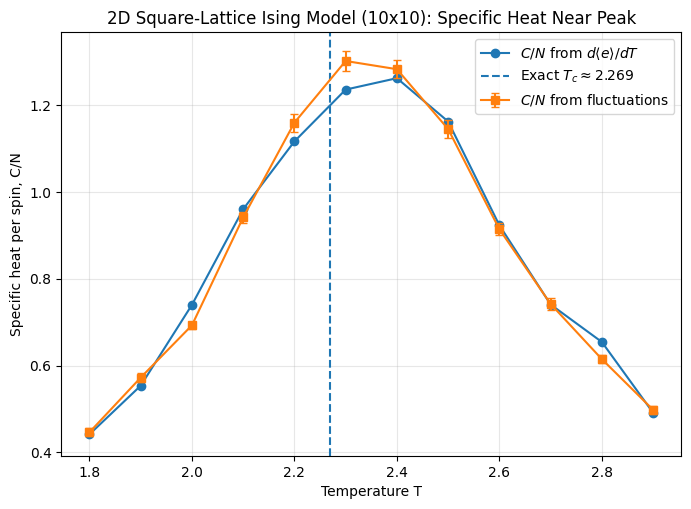


Temperature table:
   T        <e>         SEM(e)      C/N (deriv)   C/N (fluct)   SEM(C_fluct)   <|m|>
   1.00    -1.997350     0.000149      0.033600      0.022642       0.001605     0.999318
   1.10    -1.993990     0.000198      0.042525      0.041157       0.001384     0.998443
   1.20    -1.988845     0.000177      0.068325      0.065052       0.001440     0.997067
   1.30    -1.980325     0.000368      0.099275      0.101997       0.002277     0.994850
   1.40    -1.968990     0.000446      0.150125      0.140520       0.002291     0.991675
   1.50    -1.950300     0.000829      0.211775      0.203853       0.006209     0.986243
   1.60    -1.926635     0.001199      0.259500      0.267207       0.005672     0.979195
   1.70    -1.898400     0.001127      0.337450      0.337639       0.005828     0.970090
   1.80    -1.859145     0.001587      0.441825      0.446594       0.009717     0.956738
   1.90    -1.810035     0.001913      0.553825      0.572440       0.010117     0.93

In [ ]:
# Problem 2 - Specific heat of the 2D square-lattice Ising model (10x10)
# Google Colab ready
#
# Computes C(T) in two ways:
# 1) By differentiating the mean energy per spin e(T)
# 2) By the fluctuation-dissipation theorem
#
# Uses a fast checkerboard Metropolis update.

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# User inputs
# ============================================================

L = 10
N = L * L
J = 1.0
kB = 1.0
Tc_exact = 2.0 / np.log(1.0 + np.sqrt(2.0))  # exact Tc for infinite square lattice, J=kB=1

# Temperature grid
temps = np.arange(1.0, 5.0 + 1e-12, 0.1)

# Monte Carlo controls
n_equil = 3000
n_meas = 5000
measure_every = 5
n_runs = 8
seed = 12345

# ============================================================
# Checkerboard masks
# ============================================================

ii, jj = np.indices((L, L))
mask_even = ((ii + jj) % 2 == 0)
mask_odd = ~mask_even

# ============================================================
# Core Ising routines
# ============================================================

def init_lattice(L, mode="hot", rng=None):
    if rng is None:
        rng = np.random.default_rng()
    if mode == "hot":
        return rng.choice(np.array([-1, 1], dtype=np.int8), size=(L, L))
    elif mode == "cold":
        return np.ones((L, L), dtype=np.int8)
    else:
        raise ValueError("mode must be 'hot' or 'cold'")

def neighbor_sum(spins):
    return (
        np.roll(spins, 1, axis=0) +
        np.roll(spins, -1, axis=0) +
        np.roll(spins, 1, axis=1) +
        np.roll(spins, -1, axis=1)
    )

def metropolis_half_sweep(spins, T, rng, mask):
    nn = neighbor_sum(spins)
    dE = 2.0 * J * spins * nn
    rand = rng.random(spins.shape)
    accept = mask & ((dE <= 0.0) | (rand < np.exp(-dE / T)))
    spins[accept] *= -1

def metropolis_sweep(spins, T, rng):
    metropolis_half_sweep(spins, T, rng, mask_even)
    metropolis_half_sweep(spins, T, rng, mask_odd)

def total_energy(spins):
    # Count each bond once using right/down neighbors
    right = np.roll(spins, -1, axis=1)
    down = np.roll(spins, -1, axis=0)
    return -J * np.sum(spins * (right + down))

def magnetization_per_spin(spins):
    return np.mean(spins)

# ============================================================
# Simulation at one temperature
# ============================================================

def run_one_temperature(T, rng, start_mode="hot"):
    spins = init_lattice(L, mode=start_mode, rng=rng)

    # Equilibrate
    for _ in range(n_equil):
        metropolis_sweep(spins, T, rng)

    e_samples = []
    e2_samples = []
    abs_m_samples = []

    for sweep in range(n_meas):
        metropolis_sweep(spins, T, rng)

        if (sweep + 1) % measure_every == 0:
            E = total_energy(spins)
            e = E / N
            e_samples.append(e)
            e2_samples.append(e * e)
            abs_m_samples.append(abs(magnetization_per_spin(spins)))

    return (
        np.array(e_samples),
        np.array(e2_samples),
        np.array(abs_m_samples)
    )

# ============================================================
# Sweep over temperature
# ============================================================

def simulate_vs_temperature():
    rng_master = np.random.default_rng(seed)

    e_mean = []
    e_sem = []

    c_fluct_mean = []
    c_fluct_sem = []

    m_mean = []
    m_sem = []

    for T in temps:
        run_e_means = []
        run_c_fluct = []
        run_m_means = []

        for _ in range(n_runs):
            rng = np.random.default_rng(int(rng_master.integers(0, 2**32 - 1)))

            e_samples, e2_samples, abs_m_samples = run_one_temperature(
                T=T,
                rng=rng,
                start_mode="hot"
            )

            e_bar = np.mean(e_samples)
            e2_bar = np.mean(e2_samples)
            m_bar = np.mean(abs_m_samples)

            # Specific heat per spin from fluctuation-dissipation theorem:
            # C/N = N * ( <e^2> - <e>^2 ) / (k_B T^2)
            c_bar = N * (e2_bar - e_bar**2) / (kB * T**2)

            run_e_means.append(e_bar)
            run_c_fluct.append(c_bar)
            run_m_means.append(m_bar)

        run_e_means = np.array(run_e_means)
        run_c_fluct = np.array(run_c_fluct)
        run_m_means = np.array(run_m_means)

        e_mean.append(np.mean(run_e_means))
        e_sem.append(np.std(run_e_means, ddof=1) / np.sqrt(n_runs) if n_runs > 1 else 0.0)

        c_fluct_mean.append(np.mean(run_c_fluct))
        c_fluct_sem.append(np.std(run_c_fluct, ddof=1) / np.sqrt(n_runs) if n_runs > 1 else 0.0)

        m_mean.append(np.mean(run_m_means))
        m_sem.append(np.std(run_m_means, ddof=1) / np.sqrt(n_runs) if n_runs > 1 else 0.0)

        print(
            f"T = {T:.2f} done: "
            f"<e> = {e_mean[-1]:.6f} ± {e_sem[-1]:.6f}, "
            f"C/N (fluct) = {c_fluct_mean[-1]:.6f} ± {c_fluct_sem[-1]:.6f}"
        )

    return (
        np.array(e_mean), np.array(e_sem),
        np.array(c_fluct_mean), np.array(c_fluct_sem),
        np.array(m_mean), np.array(m_sem)
    )

# ============================================================
# Numerical derivative for specific heat
# ============================================================

def derivative_specific_heat(temps, e_mean):
    """
    Specific heat per spin from de/dT using finite differences.
    Uses central difference in the interior and one-sided at the ends.
    """
    c_deriv = np.zeros_like(e_mean)

    # one-sided at first point
    c_deriv[0] = (e_mean[1] - e_mean[0]) / (temps[1] - temps[0])

    # central differences
    for i in range(1, len(temps) - 1):
        c_deriv[i] = (e_mean[i + 1] - e_mean[i - 1]) / (temps[i + 1] - temps[i - 1])

    # one-sided at last point
    c_deriv[-1] = (e_mean[-1] - e_mean[-2]) / (temps[-1] - temps[-2])

    return c_deriv

# ============================================================
# Run simulation
# ============================================================

(
    e_mean, e_sem,
    c_fluct_mean, c_fluct_sem,
    m_mean, m_sem
) = simulate_vs_temperature()

c_deriv = derivative_specific_heat(temps, e_mean)

# ============================================================
# Compare accuracy of the two methods
# ============================================================

# A simple diagnostic: RMS difference between the two curves
rms_diff = np.sqrt(np.mean((c_deriv - c_fluct_mean) ** 2))

# Peak locations
peak_idx_fluct = np.argmax(c_fluct_mean)
peak_idx_deriv = np.argmax(c_deriv)

T_peak_fluct = temps[peak_idx_fluct]
T_peak_deriv = temps[peak_idx_deriv]

C_peak_fluct = c_fluct_mean[peak_idx_fluct]
C_peak_deriv = c_deriv[peak_idx_deriv]

# ============================================================
# Print summary
# ============================================================

print("\n" + "=" * 72)
print("SUMMARY")
print("=" * 72)
print(f"Lattice size L = {L} x {L}")
print(f"Exact infinite-lattice Tc = {Tc_exact:.6f}")
print()
print("Specific heat by energy derivative:")
print(f"  peak C/N  = {C_peak_deriv:.6f}")
print(f"  peak at T = {T_peak_deriv:.2f}")
print()
print("Specific heat by fluctuation-dissipation theorem:")
print(f"  peak C/N  = {C_peak_fluct:.6f}")
print(f"  peak at T = {T_peak_fluct:.2f}")
print()
print(f"RMS difference between the two C/N curves = {rms_diff:.6f}")
print()
print("Interpretation:")
print("  The two methods should agree overall.")
print("  The fluctuation-based method is usually more accurate for a fixed")
print("  amount of computer time, because numerical differentiation amplifies noise.")
print("=" * 72)

# ============================================================
# Plots
# ============================================================

# Magnetization vs T (optional but useful sanity check)
plt.figure(figsize=(7, 5))
plt.errorbar(temps, m_mean, yerr=m_sem, fmt='o-', capsize=3, label=r'$\langle |m| \rangle$')
plt.axvline(Tc_exact, linestyle='--', label=fr'Exact $T_c \approx {Tc_exact:.3f}$')
plt.xlabel('Temperature T')
plt.ylabel(r'Magnetization per spin, $\langle |m| \rangle$')
plt.title(f'2D Square-Lattice Ising Model ({L}x{L}): Magnetization vs Temperature')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Energy vs T
plt.figure(figsize=(7, 5))
plt.errorbar(temps, e_mean, yerr=e_sem, fmt='o-', capsize=3, label='Simulation')
plt.axvline(Tc_exact, linestyle='--', label=fr'Exact $T_c \approx {Tc_exact:.3f}$')
plt.xlabel('Temperature T')
plt.ylabel('Energy per spin')
plt.title(f'2D Square-Lattice Ising Model ({L}x{L}): Energy vs Temperature')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Specific heat comparison
plt.figure(figsize=(8, 5.5))
plt.plot(temps, c_deriv, 'o-', label=r'$C/N$ from $d\langle e\rangle/dT$')
plt.errorbar(
    temps, c_fluct_mean, yerr=c_fluct_sem,
    fmt='s-', capsize=3, label=r'$C/N$ from fluctuations'
)
plt.axvline(Tc_exact, linestyle='--', label=fr'Exact $T_c \approx {Tc_exact:.3f}$')
plt.xlabel('Temperature T')
plt.ylabel('Specific heat per spin, C/N')
plt.title(f'2D Square-Lattice Ising Model ({L}x{L}): Specific Heat vs Temperature')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Zoom near peak
zoom_mask = (temps >= 1.8) & (temps <= 3.0)
plt.figure(figsize=(8, 5.5))
plt.plot(temps[zoom_mask], c_deriv[zoom_mask], 'o-', label=r'$C/N$ from $d\langle e\rangle/dT$')
plt.errorbar(
    temps[zoom_mask], c_fluct_mean[zoom_mask], yerr=c_fluct_sem[zoom_mask],
    fmt='s-', capsize=3, label=r'$C/N$ from fluctuations'
)
plt.axvline(Tc_exact, linestyle='--', label=fr'Exact $T_c \approx {Tc_exact:.3f}$')
plt.xlabel('Temperature T')
plt.ylabel('Specific heat per spin, C/N')
plt.title(f'2D Square-Lattice Ising Model ({L}x{L}): Specific Heat Near Peak')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Table output
# ============================================================

print("\nTemperature table:")
print("   T        <e>         SEM(e)      C/N (deriv)   C/N (fluct)   SEM(C_fluct)   <|m|>")
for T, e, de, cd, cf, dcf, m in zip(
    temps, e_mean, e_sem, c_deriv, c_fluct_mean, c_fluct_sem, m_mean
):
    print(f"{T:7.2f}   {e:10.6f}   {de:10.6f}   {cd:11.6f}   {cf:11.6f}   {dcf:12.6f}   {m:10.6f}")

In [ ]:
# Problem 2 Snippets


# Checkerboard masks
ii, jj = np.indices((L, L))
mask_even = ((ii + jj) % 2 == 0)
mask_odd = ~mask_even


# Core Ising routine
def init_lattice(L, mode = "hot", rng = None):
    if rng is None:
        rng = np.random.default_rng();
    if mode == "hot":
        return rng.choice(np.array([-1, 1], dtype = np.int8), size = (L, L));
    elif mode == "cold":
        return np.ones((L, L), dtype = np.int8);
    else:
        raise ValueError("mode must be 'hot' or 'cold'");


def metropolis_half_sweep(spins, T, rng, mask):
    nn = neighbor_sum(spins);
    dE = 2.0 * J * spins * nn;
    rand = rng.random(spins.shape);
    accept = mask & ((dE <= 0.0) | (rand < np.exp(-dE / T)));
    spins[accept] *= -1;


def total_energy(spins):
    # Count each bond once using right/down neighbors
    right = np.roll(spins, -1, axis = 1);
    down = np.roll(spins, -1, axis = 0);
    return -J * np.sum(spins * (right + down));


# Simulation at one temperature
def run_one_temperature(T, rng, start_mode = "hot"):
    spins = init_lattice(L, mode = start_mode, rng = rng);
    # Equilibrate
    for _ in range(n_equil):
        metropolis_sweep(spins, T, rng);
    #endfor
    e_samples = [];
    e2_samples = [];
    abs_m_samples = [];

    for sweep in range(n_meas):
        metropolis_sweep(spins, T, rng);

        if (sweep + 1) % measure_every == 0:
            E = total_energy(spins);
            e = E / N;
            e_samples.append(e);
            e2_samples.append(e * e);
            abs_m_samples.append(abs(magnetization_per_spin(spins)));

    return (np.array(e_samples), np.array(e2_samples), np.array(abs_m_samples));


# Sweep over temperature
def simulate_vs_temperature():
    rng_master = np.random.default_rng(seed);
    e_mean = []; e_sem = [];
    c_fluct_mean = []; c_fluct_sem = [];
    m_mean = []; m_sem = [];
    for T in temps:
        run_e_means = [];
        run_c_fluct = [];
        run_m_means = [];
        for _ in range(n_runs):
            rng = np.random.default_rng(int(rng_master.integers(0, 2**32 - 1)));
            e_samples, e2_samples, abs_m_samples = run_one_temperature(T = T, rng = rng, start_mode = "hot");
            e_bar = np.mean(e_samples);
            e2_bar = np.mean(e2_samples);
            m_bar = np.mean(abs_m_samples);
            # Specific heat per spin from fluctuation-dissipation theorem
            c_bar = N * (e2_bar - e_bar**2) / (kB * T**2);
            run_e_means.append(e_bar);
            run_c_fluct.append(c_bar);
            run_m_means.append(m_bar);
        #endfor
        run_e_means = np.array(run_e_means);
        run_c_fluct = np.array(run_c_fluct);
        run_m_means = np.array(run_m_means);
        e_mean.append(np.mean(run_e_means));
        e_sem.append(np.std(run_e_means, ddof = 1) / np.sqrt(n_runs) if n_runs > 1 else 0.0);
        c_fluct_mean.append(np.mean(run_c_fluct));
        c_fluct_sem.append(np.std(run_c_fluct, ddof = 1) / np.sqrt(n_runs) if n_runs > 1 else 0.0);
        m_mean.append(np.mean(run_m_means));
        m_sem.append(np.std(run_m_means, ddof = 1) / np.sqrt(n_runs) if n_runs > 1 else 0.0);
        print(f"T = {T:.2f} done: " f"<e> = {e_mean[-1]:.6f} ± {e_sem[-1]:.6f}, " f"C/N (fluct) = {c_fluct_mean[-1]:.6f} ± {c_fluct_sem[-1]:.6f}");
    #endfor
    return (np.array(e_mean), np.array(e_sem), np.array(c_fluct_mean), np.array(c_fluct_sem), np.array(m_mean), np.array(m_sem));


# Numerical derivative for specific heat
def derivative_specific_heat(temps, e_mean):
    c_deriv = np.zeros_like(e_mean);
    # one-sided at first point
    c_deriv[0] = (e_mean[1] - e_mean[0]) / (temps[1] - temps[0]);
    # central differences
    for i in range(1, len(temps) - 1):
        c_deriv[i] = (e_mean[i + 1] - e_mean[i - 1]) / (temps[i + 1] - temps[i - 1]);
    # one-sided at last point
    c_deriv[-1] = (e_mean[-1] - e_mean[-2]) / (temps[-1] - temps[-2]);

    return c_deriv;

H =  0.0050, T =  2.180 : <m> =  0.819743 ± 0.002756, chi = 1.907988 ± 0.247556
H =  0.0050, T =  2.220 : <m> =  0.783978 ± 0.003056, chi = 2.890741 ± 0.399497
H =  0.0050, T =  2.240 : <m> =  0.753789 ± 0.003744, chi = 5.054588 ± 0.884409
H =  0.0050, T =  2.300 : <m> =  0.598384 ± 0.022051, chi = 35.402460 ± 12.505244
H =  0.0050, T =  2.340 : <m> =  0.448843 ± 0.012339, chi = 50.228409 ± 8.818069
H =  0.0050, T =  2.380 : <m> =  0.332181 ± 0.029434, chi = 43.162903 ± 9.170489
H =  0.0100, T =  2.180 : <m> =  0.831009 ± 0.000268, chi = 1.541834 ± 0.058354
H =  0.0100, T =  2.220 : <m> =  0.794637 ± 0.001566, chi = 2.861282 ± 0.189469
H =  0.0100, T =  2.240 : <m> =  0.777143 ± 0.001838, chi = 2.702247 ± 0.132471
H =  0.0100, T =  2.300 : <m> =  0.688593 ± 0.005033, chi = 7.228210 ± 0.717533
H =  0.0100, T =  2.340 : <m> =  0.603669 ± 0.005734, chi = 12.322023 ± 0.796536
H =  0.0100, T =  2.380 : <m> =  0.501836 ± 0.008752, chi = 19.080090 ± 2.135410
H =  0.0200, T =  2.180 : <m> =  0

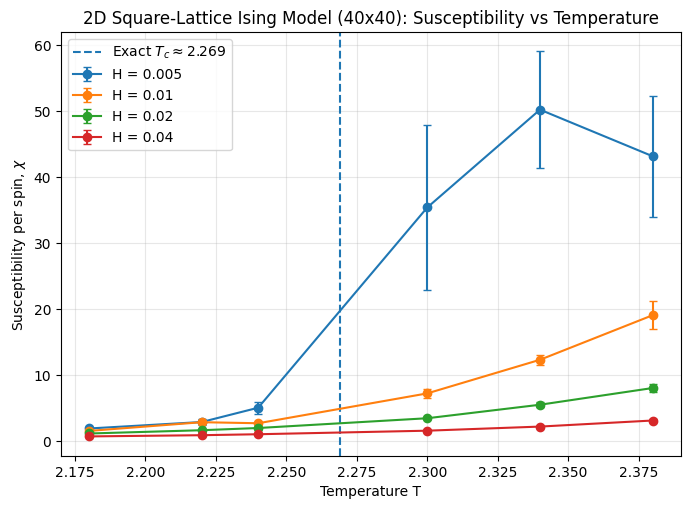

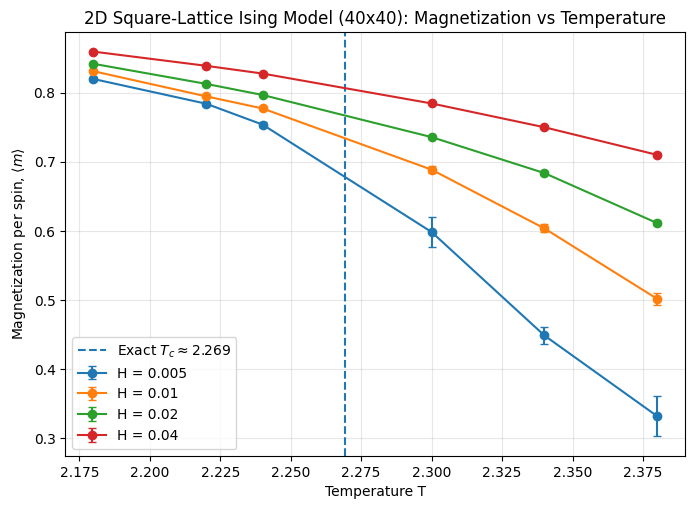

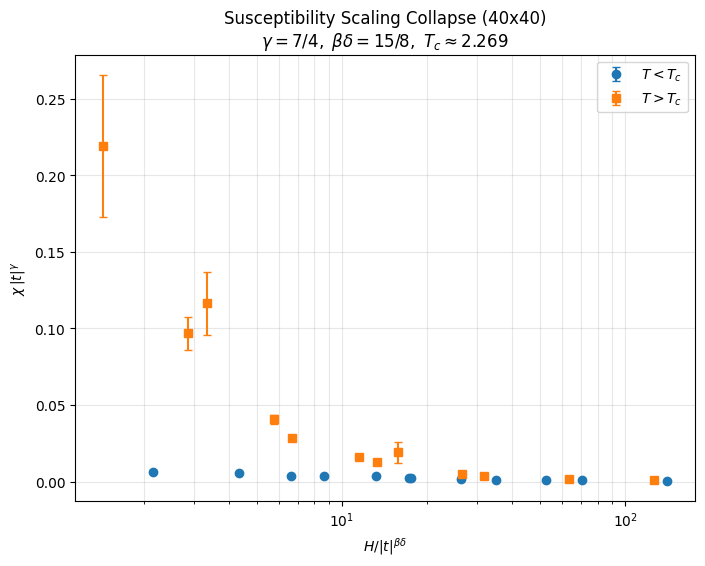

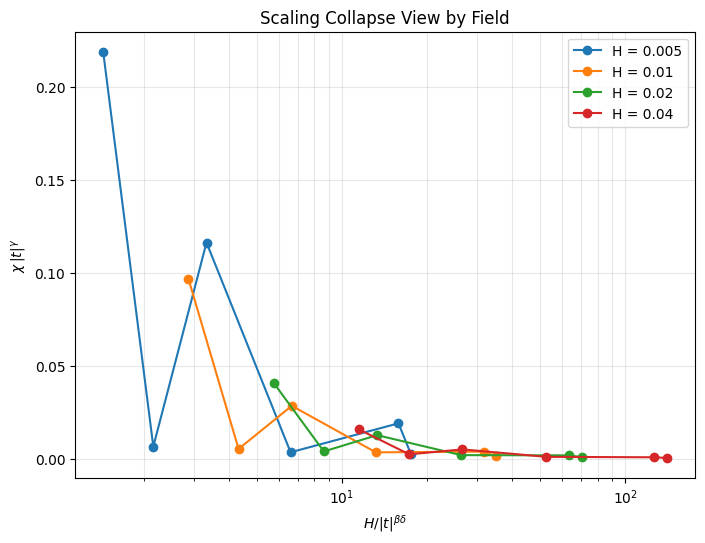


Data table:
    H        T         t            <m>         SEM(m)        chi        SEM(chi)       <e>
  0.0050    2.180   -0.039303     0.819743     0.002756     1.907988     0.247556    -1.586410
  0.0050    2.220   -0.021675     0.783978     0.003056     2.890741     0.399497    -1.538160
  0.0050    2.240   -0.012862     0.753789     0.003744     5.054588     0.884409    -1.508480
  0.0050    2.300    0.013580     0.598384     0.022051    35.402460    12.505244    -1.402419
  0.0050    2.340    0.031207     0.448843     0.012339    50.228409     8.818069    -1.324479
  0.0050    2.380    0.048835     0.332181     0.029434    43.162903     9.170489    -1.255844
  0.0100    2.180   -0.039303     0.831009     0.000268     1.541834     0.058354    -1.602616
  0.0100    2.220   -0.021675     0.794637     0.001566     2.861282     0.189469    -1.552795
  0.0100    2.240   -0.012862     0.777143     0.001838     2.702247     0.132471    -1.527021
  0.0100    2.300    0.013580     0.6885

In [ ]:
# Problem 3 - Susceptibility scaling collapse for the 2D square-lattice Ising model
# Google Colab ready
#
# Computes susceptibility chi(T,H) near the critical point
# using the fluctuation formula, then tests scaling collapse:
#
#   chi(t,h) = |t|^{-gamma} g_\pm( h / |t|^{beta*delta} )
#
# with 2D Ising exponents:
#   gamma = 7/4
#   beta  = 1/8
#   delta = 15
#   beta*delta = 15/8
#
# Main output:
#   1) chi vs T for several H
#   2) scaling-collapse plot: chi |t|^gamma vs H / |t|^(beta*delta)

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# User inputs
# ============================================================

L = 40
N = L * L
J = 1.0
kB = 1.0

Tc_exact = 2.0 / np.log(1.0 + np.sqrt(2.0))  # exact Tc for 2D square lattice, J=kB=1

# Critical exponents for 2D Ising
gamma_exp = 7.0 / 4.0
beta_exp = 1.0 / 8.0
delta_exp = 15.0
beta_delta = beta_exp * delta_exp   # 15/8 = 1.875

# Temperatures around Tc, but not exactly at Tc
temps = np.array([2.18, 2.22, 2.24, 2.30, 2.34, 2.38])

# Small positive fields
fields = np.array([0.005, 0.010, 0.020, 0.040])

# Monte Carlo controls
n_equil = 2500
n_meas = 4000
measure_every = 5
n_runs = 4
seed = 12345

# Warm-start settings
# This makes the simulation faster and usually cleaner:
# start from ordered state below Tc, random state above Tc
use_smart_initialization = True

# ============================================================
# Checkerboard masks
# ============================================================

ii, jj = np.indices((L, L))
mask_even = ((ii + jj) % 2 == 0)
mask_odd = ~mask_even

# ============================================================
# Core Ising routines with external field H
# ============================================================

def init_lattice(L, mode="hot", rng=None):
    if rng is None:
        rng = np.random.default_rng()
    if mode == "hot":
        return rng.choice(np.array([-1, 1], dtype=np.int8), size=(L, L))
    elif mode == "cold_up":
        return np.ones((L, L), dtype=np.int8)
    elif mode == "cold_down":
        return -np.ones((L, L), dtype=np.int8)
    else:
        raise ValueError("mode must be 'hot', 'cold_up', or 'cold_down'")

def neighbor_sum(spins):
    return (
        np.roll(spins, 1, axis=0) +
        np.roll(spins, -1, axis=0) +
        np.roll(spins, 1, axis=1) +
        np.roll(spins, -1, axis=1)
    )

def metropolis_half_sweep(spins, T, H, rng, mask):
    nn = neighbor_sum(spins)
    # Delta E = 2 s_i (J * sum_nn + H)
    dE = 2.0 * spins * (J * nn + H)

    rand = rng.random(spins.shape)
    accept = mask & ((dE <= 0.0) | (rand < np.exp(-dE / (kB * T))))
    spins[accept] *= -1

def metropolis_sweep(spins, T, H, rng):
    metropolis_half_sweep(spins, T, H, rng, mask_even)
    metropolis_half_sweep(spins, T, H, rng, mask_odd)

def total_energy(spins, H):
    # interaction term: count each bond once
    right = np.roll(spins, -1, axis=1)
    down = np.roll(spins, -1, axis=0)
    E_int = -J * np.sum(spins * (right + down))
    E_field = -H * np.sum(spins)
    return E_int + E_field

def magnetization_per_spin(spins):
    return np.mean(spins)

# ============================================================
# One (T,H) run
# ============================================================

def choose_initial_mode(T, H):
    if not use_smart_initialization:
        return "hot"
    if T < Tc_exact:
        # Positive H favors up spins
        return "cold_up" if H >= 0 else "cold_down"
    else:
        return "hot"

def run_one_state(T, H, rng):
    mode = choose_initial_mode(T, H)
    spins = init_lattice(L, mode=mode, rng=rng)

    # Equilibrate
    for _ in range(n_equil):
        metropolis_sweep(spins, T, H, rng)

    m_samples = []
    m2_samples = []
    e_samples = []

    for sweep in range(n_meas):
        metropolis_sweep(spins, T, H, rng)

        if (sweep + 1) % measure_every == 0:
            m = magnetization_per_spin(spins)
            e = total_energy(spins, H) / N
            m_samples.append(m)
            m2_samples.append(m * m)
            e_samples.append(e)

    return np.array(m_samples), np.array(m2_samples), np.array(e_samples)

# ============================================================
# Full sweep over temperatures and fields
# ============================================================

def simulate_grid():
    rng_master = np.random.default_rng(seed)

    results = []

    for H in fields:
        for T in temps:
            run_m_mean = []
            run_m2_mean = []
            run_chi = []
            run_e_mean = []

            for _ in range(n_runs):
                rng = np.random.default_rng(int(rng_master.integers(0, 2**32 - 1)))

                m_samples, m2_samples, e_samples = run_one_state(T, H, rng)

                m_bar = np.mean(m_samples)
                m2_bar = np.mean(m2_samples)
                e_bar = np.mean(e_samples)

                # susceptibility per spin from fluctuations:
                # chi = N ( <m^2> - <m>^2 ) / (k_B T)
                chi_bar = N * (m2_bar - m_bar**2) / (kB * T)

                run_m_mean.append(m_bar)
                run_m2_mean.append(m2_bar)
                run_e_mean.append(e_bar)
                run_chi.append(chi_bar)

            run_m_mean = np.array(run_m_mean)
            run_m2_mean = np.array(run_m2_mean)
            run_e_mean = np.array(run_e_mean)
            run_chi = np.array(run_chi)

            entry = {
                "T": T,
                "H": H,
                "t": (T - Tc_exact) / Tc_exact,

                "m_mean": np.mean(run_m_mean),
                "m_sem": np.std(run_m_mean, ddof=1) / np.sqrt(n_runs) if n_runs > 1 else 0.0,

                "m2_mean": np.mean(run_m2_mean),
                "m2_sem": np.std(run_m2_mean, ddof=1) / np.sqrt(n_runs) if n_runs > 1 else 0.0,

                "e_mean": np.mean(run_e_mean),
                "e_sem": np.std(run_e_mean, ddof=1) / np.sqrt(n_runs) if n_runs > 1 else 0.0,

                "chi_mean": np.mean(run_chi),
                "chi_sem": np.std(run_chi, ddof=1) / np.sqrt(n_runs) if n_runs > 1 else 0.0,
            }

            results.append(entry)

            print(
                f"H = {H:7.4f}, T = {T:6.3f} : "
                f"<m> = {entry['m_mean']: .6f} ± {entry['m_sem']:.6f}, "
                f"chi = {entry['chi_mean']:.6f} ± {entry['chi_sem']:.6f}"
            )

    return results

# ============================================================
# Scaling-collapse processing
# ============================================================

def build_collapse_arrays(results):
    X_plus, Y_plus, dY_plus = [], [], []
    X_minus, Y_minus, dY_minus = [], [], []

    for r in results:
        t = r["t"]
        H = r["H"]
        chi = r["chi_mean"]
        dchi = r["chi_sem"]

        if np.isclose(t, 0.0):
            continue

        abs_t = abs(t)
        X = H / (abs_t ** beta_delta)
        Y = chi * (abs_t ** gamma_exp)
        dY = dchi * (abs_t ** gamma_exp)

        if t > 0:
            X_plus.append(X)
            Y_plus.append(Y)
            dY_plus.append(dY)
        else:
            X_minus.append(X)
            Y_minus.append(Y)
            dY_minus.append(dY)

    return (
        np.array(X_plus), np.array(Y_plus), np.array(dY_plus),
        np.array(X_minus), np.array(Y_minus), np.array(dY_minus)
    )

# ============================================================
# Run the simulation
# ============================================================

results = simulate_grid()

# Sort results for prettier tables and plotting
results = sorted(results, key=lambda r: (r["H"], r["T"]))

(
    X_plus, Y_plus, dY_plus,
    X_minus, Y_minus, dY_minus
) = build_collapse_arrays(results)

# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 78)
print("SUMMARY")
print("=" * 78)
print(f"Lattice size L = {L} x {L}")
print(f"Exact Tc = {Tc_exact:.6f}")
print(f"gamma = {gamma_exp:.6f}")
print(f"beta*delta = {beta_delta:.6f}")
print()
print("Scaling variables used:")
print("  t = (T - Tc)/Tc")
print("  X = H / |t|^(beta*delta)")
print("  Y = chi * |t|^gamma")
print()
print("Interpretation:")
print("  If scaling holds, the rescaled points for T > Tc should collapse onto")
print("  one branch g_+(X), while those for T < Tc collapse onto another branch g_-(X).")
print("  Finite-size effects and Monte Carlo noise prevent perfect collapse,")
print("  but approximate collapse near criticality is the expected result.")
print("=" * 78)

# ============================================================
# Organize data by field for raw chi(T) plots
# ============================================================

data_by_field = {}
for H in fields:
    sub = [r for r in results if np.isclose(r["H"], H)]
    sub = sorted(sub, key=lambda r: r["T"])
    data_by_field[H] = sub

# ============================================================
# Plot 1: susceptibility vs T for several H
# ============================================================

plt.figure(figsize=(8, 5.5))
for H in fields:
    sub = data_by_field[H]
    Tvals = np.array([r["T"] for r in sub])
    chivals = np.array([r["chi_mean"] for r in sub])
    chisem = np.array([r["chi_sem"] for r in sub])

    plt.errorbar(Tvals, chivals, yerr=chisem, fmt='o-', capsize=3, label=fr'H = {H:g}')

plt.axvline(Tc_exact, linestyle='--', label=fr'Exact $T_c \approx {Tc_exact:.3f}$')
plt.xlabel('Temperature T')
plt.ylabel(r'Susceptibility per spin, $\chi$')
plt.title(f'2D Square-Lattice Ising Model ({L}x{L}): Susceptibility vs Temperature')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot 2: magnetization vs T for several H (optional sanity check)
# ============================================================

plt.figure(figsize=(8, 5.5))
for H in fields:
    sub = data_by_field[H]
    Tvals = np.array([r["T"] for r in sub])
    mvals = np.array([r["m_mean"] for r in sub])
    msem = np.array([r["m_sem"] for r in sub])

    plt.errorbar(Tvals, mvals, yerr=msem, fmt='o-', capsize=3, label=fr'H = {H:g}')

plt.axvline(Tc_exact, linestyle='--', label=fr'Exact $T_c \approx {Tc_exact:.3f}$')
plt.xlabel('Temperature T')
plt.ylabel(r'Magnetization per spin, $\langle m \rangle$')
plt.title(f'2D Square-Lattice Ising Model ({L}x{L}): Magnetization vs Temperature')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot 3: scaling collapse
# ============================================================

plt.figure(figsize=(8, 5.8))

# Sort by X for prettier plotting
if len(X_minus) > 0:
    idxm = np.argsort(X_minus)
    plt.errorbar(
        X_minus[idxm], Y_minus[idxm], yerr=dY_minus[idxm],
        fmt='o', capsize=3, label=r'$T < T_c$'
    )

if len(X_plus) > 0:
    idxp = np.argsort(X_plus)
    plt.errorbar(
        X_plus[idxp], Y_plus[idxp], yerr=dY_plus[idxp],
        fmt='s', capsize=3, label=r'$T > T_c$'
    )

plt.xscale('log')
plt.xlabel(r'$H / |t|^{\beta\delta}$')
plt.ylabel(r'$\chi\,|t|^\gamma$')
plt.title(
    rf'Susceptibility Scaling Collapse ({L}x{L})' + "\n" +
    rf'$\gamma=7/4,\ \beta\delta=15/8,\ T_c \approx {Tc_exact:.3f}$'
)
plt.legend()
plt.grid(alpha=0.3, which='both')
plt.show()

# ============================================================
# Plot 4: same collapse, but colored by field (sometimes helpful)
# ============================================================

plt.figure(figsize=(8, 5.8))

for H in fields:
    sub = [r for r in results if np.isclose(r["H"], H)]
    Xvals = []
    Yvals = []
    for r in sub:
        t = r["t"]
        if np.isclose(t, 0.0):
            continue
        abs_t = abs(t)
        Xvals.append(H / (abs_t ** beta_delta))
        Yvals.append(r["chi_mean"] * (abs_t ** gamma_exp))
    Xvals = np.array(Xvals)
    Yvals = np.array(Yvals)

    idx = np.argsort(Xvals)
    plt.plot(Xvals[idx], Yvals[idx], 'o-', label=fr'H = {H:g}')

plt.xscale('log')
plt.xlabel(r'$H / |t|^{\beta\delta}$')
plt.ylabel(r'$\chi\,|t|^\gamma$')
plt.title('Scaling Collapse View by Field')
plt.legend()
plt.grid(alpha=0.3, which='both')
plt.show()

# ============================================================
# Table output
# ============================================================

print("\nData table:")
print("    H        T         t            <m>         SEM(m)        chi        SEM(chi)       <e>")
for r in results:
    print(
        f"{r['H']:8.4f}  "
        f"{r['T']:7.3f}  "
        f"{r['t']:10.6f}  "
        f"{r['m_mean']:11.6f}  "
        f"{r['m_sem']:11.6f}  "
        f"{r['chi_mean']:11.6f}  "
        f"{r['chi_sem']:11.6f}  "
        f"{r['e_mean']:11.6f}"
    )

In [ ]:
# Problem 3 - Snippets


# Core Ising routine with external field H
def init_lattice(L, mode = "hot", rng = None):
    if rng is None:
        rng = np.random.default_rng();
    if mode == "hot":
        return rng.choice(np.array([-1, 1], dtype = np.int8), size = (L, L));
    elif mode == "cold_up":
        return np.ones((L, L), dtype = np.int8);
    elif mode == "cold_down":
        return -np.ones((L, L), dtype = np.int8);
    else:
        raise ValueError("mode must be 'hot', 'cold_up', or 'cold_down'");

def metropolis_half_sweep(spins, T, H, rng, mask):
    nn = neighbor_sum(spins);
    dE = 2.0 * spins * (J * nn + H);
    rand = rng.random(spins.shape);
    accept = mask & ((dE <= 0.0) | (rand < np.exp(-dE / (kB * T))));
    spins[accept] *= -1;


def total_energy(spins, H):
    # interaction term: count each bond once
    right = np.roll(spins, -1, axis = 1);
    down = np.roll(spins, -1, axis = 0);
    E_int = -J * np.sum(spins * (right + down));
    E_field = -H * np.sum(spins);
    return E_int + E_field;


# One (T,H) run
def choose_initial_mode(T, H):
    if not use_smart_initialization:
        return "hot";
    if T < Tc_exact:
        # Positive H favors up spins
        return "cold_up" if H >= 0 else "cold_down";
    else:
        return "hot";

def run_one_state(T, H, rng):
    mode = choose_initial_mode(T, H);
    spins = init_lattice(L, mode = mode, rng = rng);
    # Equilibrate
    for _ in range(n_equil):
        metropolis_sweep(spins, T, H, rng);
    #endfor
    m_samples = [];
    m2_samples = [];
    e_samples = [];

    for sweep in range(n_meas):
        metropolis_sweep(spins, T, H, rng);
        if (sweep + 1) % measure_every == 0:
            m = magnetization_per_spin(spins);
            e = total_energy(spins, H) / N;
            m_samples.append(m);
            m2_samples.append(m * m);
            e_samples.append(e);
    #endfor
    return np.array(m_samples), np.array(m2_samples), np.array(e_samples);


# Full sweep over temperatures and fields
def simulate_grid():
    rng_master = np.random.default_rng(seed);
    results = [];
    for H in fields:
        for T in temps:
            run_m_mean = [];  run_m2_mean = [];
            run_chi = [];  run_e_mean = [];
            for _ in range(n_runs):
                rng = np.random.default_rng(int(rng_master.integers(0, 2**32 - 1)));
                m_samples, m2_samples, e_samples = run_one_state(T, H, rng);
                m_bar = np.mean(m_samples);
                m2_bar = np.mean(m2_samples);
                e_bar = np.mean(e_samples);
                # susceptibility per spin from fluctuations:
                chi_bar = N * (m2_bar - m_bar**2) / (kB * T);
                run_m_mean.append(m_bar);
                run_m2_mean.append(m2_bar);
                run_e_mean.append(e_bar);
                run_chi.append(chi_bar);
            #endfor
            run_m_mean = np.array(run_m_mean);
            run_m2_mean = np.array(run_m2_mean);
            run_e_mean = np.array(run_e_mean);
            run_chi = np.array(run_chi);
            entry = {"T": T, "H": H, "t": (T - Tc_exact) / Tc_exact,
                     "m_mean": np.mean(run_m_mean), "m_sem": np.std(run_m_mean, ddof = 1) / np.sqrt(n_runs) if n_runs > 1 else 0.0,
                     "m2_mean": np.mean(run_m2_mean), "m2_sem": np.std(run_m2_mean, ddof = 1) / np.sqrt(n_runs) if n_runs > 1 else 0.0,
                     "e_mean": np.mean(run_e_mean), "e_sem": np.std(run_e_mean, ddof = 1) / np.sqrt(n_runs) if n_runs > 1 else 0.0,
                     "chi_mean": np.mean(run_chi), "chi_sem": np.std(run_chi, ddof = 1) / np.sqrt(n_runs) if n_runs > 1 else 0.0,};
            results.append(entry);
            print(f"H = {H:7.4f}, T = {T:6.3f} : " f"<m> = {entry['m_mean']: .6f} ± {entry['m_sem']:.6f}, "
                  f"chi = {entry['chi_mean']:.6f} ± {entry['chi_sem']:.6f}");
    #endfor
    return results;


# Scaling-collapse processing
def build_collapse_arrays(results):
    X_plus, Y_plus, dY_plus = [], [], [];
    X_minus, Y_minus, dY_minus = [], [], [];

    for r in results:
        t = r["t"];
        H = r["H"];
        chi = r["chi_mean"];
        dchi = r["chi_sem"];
        if np.isclose(t, 0.0):
            continue;
        abs_t = abs(t);
        X = H / (abs_t ** beta_delta);
        Y = chi * (abs_t ** gamma_exp);
        dY = dchi * (abs_t ** gamma_exp);

        if t > 0:
            X_plus.append(X);
            Y_plus.append(Y);
            dY_plus.append(dY);
        else:
            X_minus.append(X);
            Y_minus.append(Y);
            dY_minus.append(dY);

    return (np.array(X_plus), np.array(Y_plus), np.array(dY_plus),np.array(X_minus), np.array(Y_minus), np.array(dY_minus));


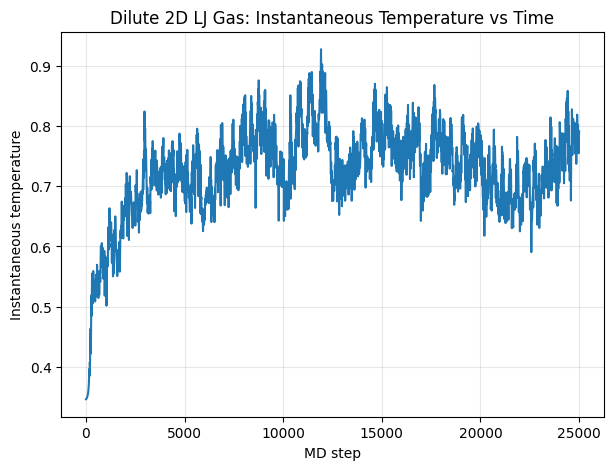

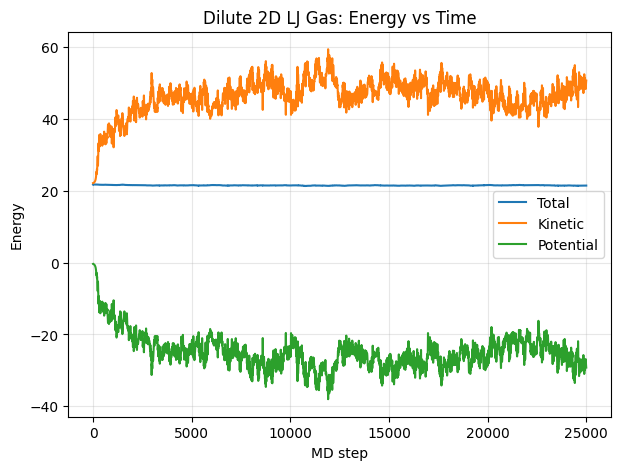

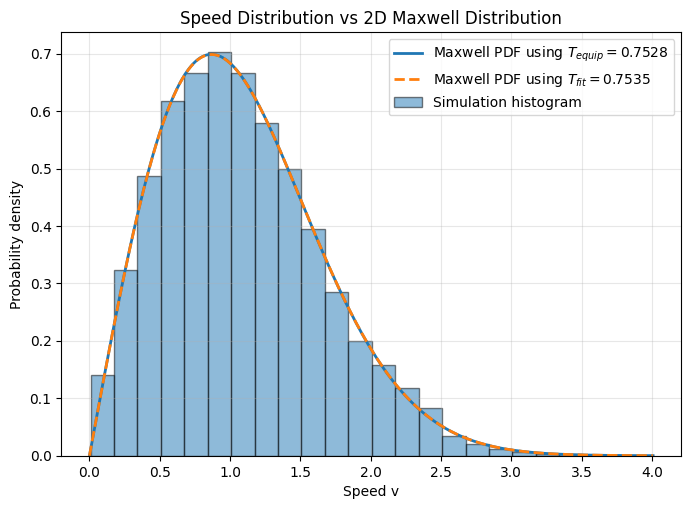

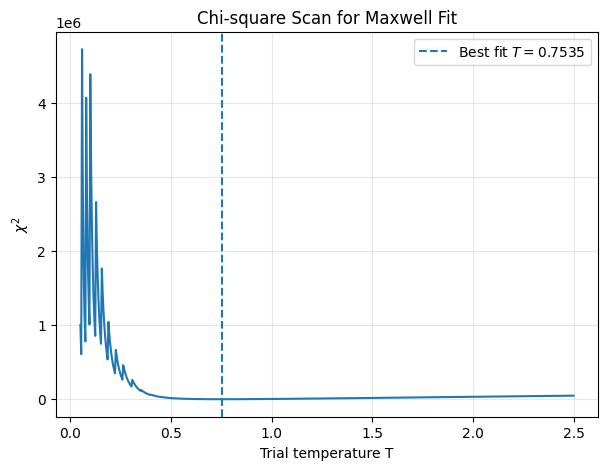


SUMMARY
N particles              = 64
Box length L             = 24.0
Density                  = 0.111111
dt                       = 0.005
Total MD steps           = 25000
Equilibration steps      = 8000
Velocity sample interval = 20
Collected particle speed samples = 54400

Temperature from equipartition     T_equip = 0.752839
Temperature from chi-square fit    T_fit   = 0.753506
Absolute difference                = 0.000667
Relative difference                = 0.09%

Best chi-square        = 153.370517
Degrees of freedom     = 20
Reduced chi-square     = 7.668526



In [ ]:
# Problem 4 - Speed distribution of a dilute 2D gas and comparison with Maxwell distribution
# Google Colab ready
#
# This code:
# 1) simulates a dilute 2D Lennard-Jones gas with velocity-Verlet
# 2) collects speed samples after equilibration
# 3) builds the measured speed histogram
# 4) compares it with the 2D Maxwell speed distribution
# 5) estimates temperature in two ways:
#       (a) from equipartition
#       (b) from a chi-square fit to the histogram
#
# Reduced units are used: m = 1, sigma = 1, epsilon = 1, k_B = 1

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# User inputs
# ============================================================

# System size / density
N_side = 8                 # particles placed initially on N_side x N_side grid
N = N_side * N_side
Lbox = 24.0                # large box -> dilute gas

# MD controls
dt = 0.005
n_steps = 25000
n_equil = 8000             # steps discarded as equilibration
sample_every = 20          # collect velocities every this many steps after equilibration
rcut = 3.0                 # LJ cutoff

# Initial conditions
v0max = 1.0                # initial random velocity component range ~ [-v0max, v0max]
disp = 0.10                # initial random displacement around lattice points
seed = 12345

# Histogram / chi-square controls
nbins = 24
fit_T_min = 0.05
fit_T_max = 2.50
fit_T_points = 600

# Chi-square bin threshold:
# only include bins with enough expected and observed counts
min_count_for_chi2 = 5

# ============================================================
# Helpers
# ============================================================

rng = np.random.default_rng(seed)

def minimum_image(dx, box_length):
    return dx - box_length * np.rint(dx / box_length)

def initialize_positions(N_side, Lbox, disp, rng):
    """
    Start from a regular grid with small random displacement.
    """
    xs = np.linspace(0, Lbox, N_side, endpoint=False) + Lbox / (2 * N_side)
    ys = np.linspace(0, Lbox, N_side, endpoint=False) + Lbox / (2 * N_side)
    xv, yv = np.meshgrid(xs, ys, indexing='ij')
    pos = np.column_stack([xv.ravel(), yv.ravel()])

    pos += rng.uniform(-disp, disp, size=pos.shape)
    pos %= Lbox
    return pos

def initialize_velocities(N, v0max, rng):
    """
    Random initial velocities with zero net momentum.
    """
    vel = rng.uniform(-v0max, v0max, size=(N, 2))
    vel -= np.mean(vel, axis=0, keepdims=True)
    return vel

def compute_forces_energy(pos, Lbox, rcut):
    """
    Compute Lennard-Jones forces and potential energy using pair loops.
    Fine for moderate N like 64.
    """
    forces = np.zeros_like(pos)
    pot = 0.0
    rcut2 = rcut * rcut

    for i in range(N - 1):
        for j in range(i + 1, N):
            dx = pos[i, 0] - pos[j, 0]
            dy = pos[i, 1] - pos[j, 1]

            dx = minimum_image(dx, Lbox)
            dy = minimum_image(dy, Lbox)

            r2 = dx * dx + dy * dy
            if r2 < rcut2 and r2 > 1e-12:
                inv_r2 = 1.0 / r2
                inv_r6 = inv_r2**3
                inv_r12 = inv_r6**2

                # LJ potential: 4[(1/r)^12 - (1/r)^6]
                pot += 4.0 * (inv_r12 - inv_r6)

                # Force magnitude factor:
                # F_vec = 24 * (2/r^14 - 1/r^8) * r_vec
                ffac = 24.0 * inv_r2 * (2.0 * inv_r12 - inv_r6)
                fx = ffac * dx
                fy = ffac * dy

                forces[i, 0] += fx
                forces[i, 1] += fy
                forces[j, 0] -= fx
                forces[j, 1] -= fy

    return forces, pot

def kinetic_energy(vel):
    return 0.5 * np.sum(vel[:, 0]**2 + vel[:, 1]**2)

def temperature_from_equipartition(vel_samples):
    """
    In reduced 2D units with m=1 and k_B=1:
        T = < (vx^2 + vy^2) / 2 >
    over all collected particle samples.
    """
    vx = vel_samples[:, 0]
    vy = vel_samples[:, 1]
    return np.mean(0.5 * (vx * vx + vy * vy))

def maxwell_speed_pdf_2d(v, T):
    """
    2D Maxwell speed distribution in reduced units:
        P(v) = (v/T) exp(-v^2/(2T))
    """
    return (v / T) * np.exp(-v * v / (2.0 * T))

def maxwell_bin_probabilities(bin_edges, T):
    """
    Exact bin probabilities from the 2D Maxwell CDF:
        F(v) = 1 - exp(-v^2/(2T))
    So P(v in [a,b]) = exp(-a^2/(2T)) - exp(-b^2/(2T))
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]
    probs = np.exp(-a * a / (2.0 * T)) - np.exp(-b * b / (2.0 * T))
    return probs

def chi_square_for_temperature(hist_counts, bin_edges, T):
    """
    Chi-square using expected counts from Maxwell distribution.
    Ignore bins with too few expected / observed counts.
    """
    total = np.sum(hist_counts)
    expected = total * maxwell_bin_probabilities(bin_edges, T)

    mask = (expected >= min_count_for_chi2) & (hist_counts >= min_count_for_chi2)
    if np.sum(mask) < 5:
        return np.inf, 0

    chi2 = np.sum((hist_counts[mask] - expected[mask])**2 / expected[mask])
    dof = np.sum(mask) - 1 - 1   # minus 1 for normalization, minus 1 fitted parameter T
    return chi2, max(dof, 1)

# ============================================================
# Initialize
# ============================================================

pos = initialize_positions(N_side, Lbox, disp, rng)
vel = initialize_velocities(N, v0max, rng)

forces, pot = compute_forces_energy(pos, Lbox, rcut)

# Storage
vel_samples = []
time_series_T = []
time_series_KE = []
time_series_PE = []
time_series_Etot = []

# ============================================================
# Velocity-Verlet integration
# ============================================================

for step in range(n_steps):
    # position update
    pos += vel * dt + 0.5 * forces * dt * dt
    pos %= Lbox

    # half-step / new forces
    new_forces, pot = compute_forces_energy(pos, Lbox, rcut)

    # velocity update
    vel += 0.5 * (forces + new_forces) * dt
    forces = new_forces

    # diagnostics
    KE = kinetic_energy(vel)
    Tinst = KE / N  # in 2D reduced units: KE = N*T
    time_series_T.append(Tinst)
    time_series_KE.append(KE)
    time_series_PE.append(pot)
    time_series_Etot.append(KE + pot)

    # collect velocity samples after equilibration
    if step >= n_equil and ((step - n_equil) % sample_every == 0):
        vel_samples.append(vel.copy())

# Convert sampled velocities to big array of particle samples
vel_samples = np.array(vel_samples)                  # shape: (nsamples, N, 2)
vel_flat = vel_samples.reshape(-1, 2)               # shape: (nsamples * N, 2)
speeds = np.sqrt(np.sum(vel_flat**2, axis=1))

# ============================================================
# Temperature from equipartition
# ============================================================

T_equip = temperature_from_equipartition(vel_flat)

# ============================================================
# Histogram and chi-square fit
# ============================================================

hist_counts, bin_edges = np.histogram(speeds, bins=nbins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_widths = np.diff(bin_edges)

# Density histogram for plotting
hist_density, _ = np.histogram(speeds, bins=bin_edges, density=True)

# Scan T for chi-square best fit
T_trials = np.linspace(fit_T_min, fit_T_max, fit_T_points)
chi2_vals = []
chi2_red_vals = []

for Ttest in T_trials:
    chi2, dof = chi_square_for_temperature(hist_counts, bin_edges, Ttest)
    chi2_vals.append(chi2)
    chi2_red_vals.append(chi2 / dof if np.isfinite(chi2) else np.inf)

chi2_vals = np.array(chi2_vals)
chi2_red_vals = np.array(chi2_red_vals)

best_idx = np.argmin(chi2_vals)
T_fit = T_trials[best_idx]
chi2_best, dof_best = chi_square_for_temperature(hist_counts, bin_edges, T_fit)
chi2_red_best = chi2_best / dof_best

# ============================================================
# Plotting
# ============================================================

v_plot = np.linspace(0, max(np.max(speeds), 4.0), 500)
pdf_equip = maxwell_speed_pdf_2d(v_plot, T_equip)
pdf_fit = maxwell_speed_pdf_2d(v_plot, T_fit)

# 1) Temperature / energy time series
plt.figure(figsize=(7, 5))
plt.plot(time_series_T)
plt.xlabel('MD step')
plt.ylabel('Instantaneous temperature')
plt.title('Dilute 2D LJ Gas: Instantaneous Temperature vs Time')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(time_series_Etot, label='Total')
plt.plot(time_series_KE, label='Kinetic')
plt.plot(time_series_PE, label='Potential')
plt.xlabel('MD step')
plt.ylabel('Energy')
plt.title('Dilute 2D LJ Gas: Energy vs Time')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 2) Speed histogram with Maxwell fits
plt.figure(figsize=(8, 5.5))
plt.bar(
    bin_centers, hist_density, width=bin_widths, alpha=0.5,
    align='center', edgecolor='black', label='Simulation histogram'
)
plt.plot(v_plot, pdf_equip, linewidth=2, label=fr'Maxwell PDF using $T_{{equip}}={T_equip:.4f}$')
plt.plot(v_plot, pdf_fit, linewidth=2, linestyle='--', label=fr'Maxwell PDF using $T_{{fit}}={T_fit:.4f}$')
plt.xlabel('Speed v')
plt.ylabel('Probability density')
plt.title('Speed Distribution vs 2D Maxwell Distribution')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3) Chi-square scan
plt.figure(figsize=(7, 5))
plt.plot(T_trials, chi2_vals)
plt.axvline(T_fit, linestyle='--', label=fr'Best fit $T={T_fit:.4f}$')
plt.xlabel('Trial temperature T')
plt.ylabel(r'$\chi^2$')
plt.title(r'Chi-square Scan for Maxwell Fit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# Text summary
# ============================================================

print("\n" + "=" * 78)
print("SUMMARY")
print("=" * 78)
print(f"N particles              = {N}")
print(f"Box length L             = {Lbox}")
print(f"Density                  = {N / (Lbox * Lbox):.6f}")
print(f"dt                       = {dt}")
print(f"Total MD steps           = {n_steps}")
print(f"Equilibration steps      = {n_equil}")
print(f"Velocity sample interval = {sample_every}")
print(f"Collected particle speed samples = {len(speeds)}")
print()
print(f"Temperature from equipartition     T_equip = {T_equip:.6f}")
print(f"Temperature from chi-square fit    T_fit   = {T_fit:.6f}")
print(f"Absolute difference                = {abs(T_fit - T_equip):.6f}")
print(f"Relative difference                = {abs(T_fit - T_equip)/T_equip:.2%}")
print()
print(f"Best chi-square        = {chi2_best:.6f}")
print(f"Degrees of freedom     = {dof_best}")
print(f"Reduced chi-square     = {chi2_red_best:.6f}")
print()
print("=" * 78)



In [ ]:
# Problem 4 - Snippets


def minimum_image(dx, box_length):
    return dx - box_length * np.rint(dx / box_length);

# Start from a regular grid with small random displacement.
def initialize_positions(N_side, Lbox, disp, rng):
    xs = np.linspace(0, Lbox, N_side, endpoint = False) + Lbox / (2 * N_side);
    ys = np.linspace(0, Lbox, N_side, endpoint = False) + Lbox / (2 * N_side);
    xv, yv = np.meshgrid(xs, ys, indexing = 'ij');
    pos = np.column_stack([xv.ravel(), yv.ravel()]);
    pos += rng.uniform(-disp, disp, size = pos.shape);
    pos %= Lbox;
    return pos;

#Compute Lennard-Jones forces and potential energy using pair loops. Its lowkey fine for moderate N like 64.
def compute_forces_energy(pos, Lbox, rcut):
    forces = np.zeros_like(pos);
    pot = 0.0;
    rcut2 = rcut * rcut;

    for i in range(N - 1):
        for j in range(i + 1, N):
            dx = pos[i, 0] - pos[j, 0];
            dy = pos[i, 1] - pos[j, 1];
            dx = minimum_image(dx, Lbox);
            dy = minimum_image(dy, Lbox);

            r2 = dx * dx + dy * dy;
            if r2 < rcut2 and r2 > 1e-12:
                inv_r2 = 1.0 / r2;
                inv_r6 = inv_r2**3;
                inv_r12 = inv_r6**2;
                pot += 4.0 * (inv_r12 - inv_r6);  # LJ potential: 4[(1/r)^12 - (1/r)^6]

                ffac = 24.0 * inv_r2 * (2.0 * inv_r12 - inv_r6); # F_vec = 24 * (2/r^14 - 1/r^8) * r_vec
                fx = ffac * dx;
                fy = ffac * dy;

                forces[i, 0] += fx;
                forces[i, 1] += fy;
                forces[j, 0] -= fx;
                forces[j, 1] -= fy;
        #endfor
    #endfor
    return forces, pot;

# In reduced 2D units with m = 1 and k_B = 1: T = < (vx^2 + vy^2) / 2 > over all collected particle samples.
def temperature_from_equipartition(vel_samples):
    vx = vel_samples[:, 0];
    vy = vel_samples[:, 1];
    return np.mean(0.5 * (vx * vx + vy * vy));

# 2D Maxwell speed distribution in reduced units: P(v) = (v/T) exp(-v^2/(2T))
def maxwell_speed_pdf_2d(v, T):
    return (v / T) * np.exp(-v * v / (2.0 * T));

# Exact bin probabilities from the 2D Maxwell CDF: F(v) = 1 - exp(-v^2/(2T)), so P(v in [a,b]) = exp(-a^2/(2T)) - exp(-b^2/(2T))
def maxwell_bin_probabilities(bin_edges, T):
    a = bin_edges[:-1];
    b = bin_edges[1:];
    probs = np.exp(-a * a / (2.0 * T)) - np.exp(-b * b / (2.0 * T));
    return probs;

# Chi-square using expected counts from Maxwell distribution. Ignore bins with too few expected / observed counts.
def chi_square_for_temperature(hist_counts, bin_edges, T):
    total = np.sum(hist_counts);
    expected = total * maxwell_bin_probabilities(bin_edges, T);
    mask = (expected >= min_count_for_chi2) & (hist_counts >= min_count_for_chi2);
    if np.sum(mask) < 5:
        return np.inf, 0;

    chi2 = np.sum((hist_counts[mask] - expected[mask])**2 / expected[mask]);
    dof = np.sum(mask) - 1 - 1;   # minus 1 for normalization, minus 1 again for fitted parameter T
    return chi2, max(dof, 1);


# Velocity-Verlet integration
for step in range(n_steps):
    # position update
    pos += vel * dt + 0.5 * forces * dt * dt;
    pos %= Lbox;
    # half-step / new forces
    new_forces, pot = compute_forces_energy(pos, Lbox, rcut);
    # velocity update
    vel += 0.5 * (forces + new_forces) * dt;
    forces = new_forces;
    # diagnostics
    KE = kinetic_energy(vel);
    Tinst = KE / N;  # in 2D reduced units: KE = N*T
    time_series_T.append(Tinst);
    time_series_KE.append(KE);
    time_series_PE.append(pot);
    time_series_Etot.append(KE + pot);

    # collect velocity samples after equilibration
    if step >= n_equil and ((step - n_equil) % sample_every == 0):
        vel_samples.append(vel.copy());

# Convert sampled velocities to big array of particle samples
vel_samples = np.array(vel_samples);                  # shape: (nsamples, N, 2)
vel_flat = vel_samples.reshape(-1, 2);               # shape: (nsamples * N, 2)
speeds = np.sqrt(np.sum(vel_flat**2, axis = 1));
